In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nelgiriyewithana_emotions_path = kagglehub.dataset_download('nelgiriyewithana/emotions')

print('Data source import complete.')


100%|██████████| 15.7M/15.7M [00:00<00:00, 137MB/s]

Extracting files...


Data source import complete.


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Emotions Analysis | Bidirectional GRU | 0.94 Train |0.93 Test</p>

***We will do The Following Tasks in this Notebook to train a Bidirectional GRU on Emotion Analysis :***
- We Will Load Textual data and preprocess and clean the texts.
- We will do Tokenization and inter encoding using Tokeinzer Class.
- We will do Padding .
- We Will Train a Bidirectional GRU. to Get good Accuracy.
- We Will Visualize Results.
- Do Evaluations on Test Data.

![Emotions Analysis (1).png](attachment:4ad28ec5-0834-4169-870d-eefc419f3099.png)

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">About Dataset</p>

## Introduction:
Welcome to the "Emotions" dataset – a collection of English Twitter messages meticulously annotated with six fundamental emotions: anger, fear, joy, love, sadness, and surprise. This dataset serves as a valuable resource for understanding and analyzing the diverse spectrum of emotions expressed in short-form text on social media.

## About the Dataset:
Each entry in this dataset consists of a text segment representing a Twitter message and a corresponding label indicating the predominant emotion conveyed. The emotions are classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5). Whether you're interested in sentiment analysis, emotion classification, or text mining, this dataset provides a rich foundation for exploring the nuanced emotional landscape within the realm of social media.

## Key Features:
- text: A string feature representing the content of the Twitter message.
- label: A classification label indicating the primary emotion, with values ranging from 0 to 5.
## Potential Use Cases:
Sentiment Analysis: Uncover the prevailing sentiments in English Twitter messages across various emotions.
Emotion Classification: Develop models to accurately classify tweets into the six specified emotion categories.
Textual Analysis: Explore linguistic patterns and expressions associated with different emotional states.
## Sample Data:
| text                                           | label |
|------------------------------------------------|-------|
| that was what i felt when i was finally accept…| 1     |
| i take every day as it comes i'm just focussin…| 4     |
| i give you plenty of attention even when i fee…| 0     |

If you find this dataset useful consider giving it a vote! 😊❤️

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">About Author</p>
##### ***Hello, I'm  Muhammad_Abdullah : A Data Science Enthusiast and Kaggle 2x Expert***

Greetings! I'm delighted to welcome you into my world of data science exploration and innovation. I'm **Muhammad_Abdullah**, a passionate data scientist with a fervent dedication to unraveling the mysteries hidden within datasets and leveraging the power of machine learning to drive meaningful insights and solutions.

###### ***A Passion for Data Science***

Since the inception of my journey into the captivating realm of data science, I've been driven by an insatiable curiosity and an unwavering passion for uncovering the stories embedded in data. From the thrill of diving deep into complex datasets to the exhilaration of crafting predictive models that shape our understanding of the world, data science has become not just a profession but a lifelong passion.

###### ***Guiding Light on Kaggle***

As a Kaggle 2x Expert, I've had the privilege of sharing my knowledge, insights, and experiences with the vibrant Kaggle community. Through meticulously crafted notebooks, engaging discussions, and collaborative projects, I've had the opportunity to mentor aspiring data enthusiasts, foster a culture of learning and growth, and contribute to the collective pursuit of excellence in data science.

###### ***Let's Explore Together***

Join me on an exhilarating adventure into the dynamic world of data science! Together, we'll unlock the potential of data, unravel its mysteries, and embark on a transformative journey of discovery and innovation. Whether you're a seasoned data enthusiast or just beginning your data science odyssey, I'm excited to share this journey with you and explore the endless possibilities that data science has to offer.
<div style="text-align: left;">
    <table>
        <tr>
            <th><b>Website</b></th>
            <th><b>Links</b></th>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>GitHub</td>
            <td><a href="https://github.com/muhammadabdullah0303"><img src="https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github" alt="GitHub"/></a></td>
        </tr>
        <tr>
            <td>LinkedIn</td>
            <td><a href="https://www.linkedin.com/in/muhammad-abdullah-6b84b4297/"><img src="https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin" alt="LinkedIn"/></a></td>
        </tr>
        <tr>
        </tr>
        <tr>
            <td>Facebook</td>
            <td><a href="https://web.facebook.com/abd.sentaflexmental"><img src="https://img.shields.io/badge/Facebook-Profile-blue?style=for-the-badge&logo=facebook" alt="Facebook"/></a></td>
        </tr>
        <tr>
            <td>Gmail</td>
            <td><a href="mailto:mrabdullah@gmail.com"><img src="https://img.shields.io/badge/Gmail-Contact%20Me-red?style=for-the-badge&logo=gmail" alt="Gmail"/></a></td>
        </tr>
    </table>
</div>


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Importing Libraries</p>

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Word Cloud
from wordcloud import WordCloud
# from textacy import preprocessing
from nltk.stem.snowball import SnowballStemmer
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import re

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Loading Data</p>


In [4]:
# Load Data
df = pd.read_csv('FINALGRU.csv')
# Drop rows where the 'label' column has NaN values
df.dropna(subset=['label'], inplace=True)
df.head()

,tweet,label
0,i think about it i feel violent,6
1,i feel so grouchy a class post count link href...,6
2,i wonder if anyone is even looking at my mater...,8
3,i still don t feel very funny,4
4,im still feeling a bit grouchy,6


In [5]:
# Shape Of Data
print(f'The Shape Of Data Is : {df.shape}')

The Shape Of Data Is : (598880, 2)


In [6]:
# Null Values
df.isnull().sum()

,0
tweet,0
label,0


In [7]:
# Duplicates
df.duplicated().sum()

np.int64(598441)

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Renaming The Columns Names</p>


In [8]:
# Rename Columns
df.rename(columns={'tweet': 'tweet', 'label': 'Label'}, inplace=True)
# Dropping the Index Colums
#df.drop('Unnamed: 0',axis=1,inplace=True)

In [9]:
# Head Of Data
df.head()

,tweet,Label
0,i think about it i feel violent,6
1,i feel so grouchy a class post count link href...,6
2,i wonder if anyone is even looking at my mater...,8
3,i still don t feel very funny,4
4,im still feeling a bit grouchy,6


In [10]:
# Lets Rename Label also {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8'}
df['Label'] = df['Label'].replace(1.0,'1')
df['Label'] = df['Label'].replace(2.0,'2')
df['Label'] = df['Label'].replace(3.0,'3')
df['Label'] = df['Label'].replace(4.0,'4')
df['Label'] = df['Label'].replace(5.0,'5')
df['Label'] = df['Label'].replace(6.0,'6')
df['Label'] = df['Label'].replace(7.0,'7')
df['Label'] = df['Label'].replace(8.0,'8')

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Label Count</p>


/tmp/ipykernel_10052/3778936138.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")


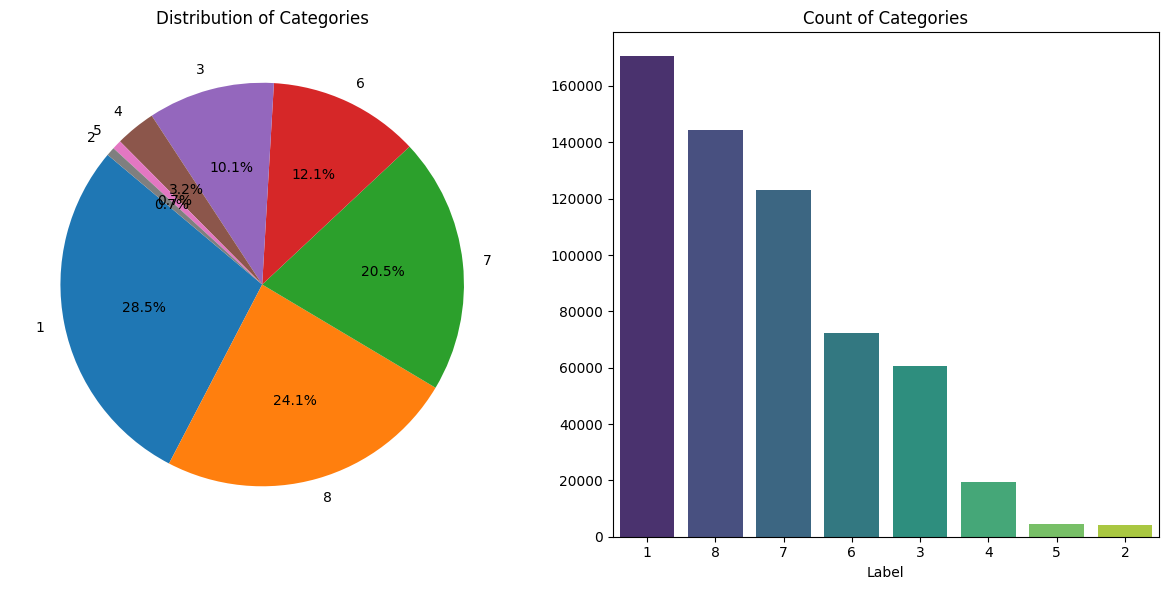

In [11]:
# Value Count Of Label
count = df['Label'].value_counts()

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Plot pie chart on the first subplot
palette = sns.color_palette("viridis")
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")
axs[1].set_title('Count of Categories')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Two Seperate Data Set for Visualizng text</p>

In [12]:
# Make Seperate Data Set to Visualize text
# 1
df_1 = df[df['Label']=='1']
# 2
df_2 = df[df['Label']=='2']
# 3
df_3 = df[df['Label']=='3']
# 4
df_4 = df[df['Label']=='4']
# 5
df_5 = df[df['Label']=='5']
# 6
df_6 = df[df['Label']=='6']
# 7
df_7 = df[df['Label']=='7']
# 8
df_8 = df[df['Label']=='8']

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Visualizing Text Using Word Cloud</p>

***A word cloud is a visual representation of text data in which the frequency of each word's occurrence is depicted by the size of the word. Words that appear more frequently in the text are typically displayed with a larger font size, while less frequent words are smaller.***

***Word clouds are often used to quickly and visually summarize the most common words or themes within a large body of text. They are popular in data analysis, text mining, and visualization tasks, as they provide a simple yet effective way to identify patterns and trends in textual data.***

In [13]:
# Combine text from different categories
combined_1_text = ' '.join(df_1['Label'])
combined_2_text = ' '.join(df_2['Label'])
combined_3_text = ' '.join(df_3['Label'])
combined_4_text = ' '.join(df_4['Label'])
combined_5_text = ' '.join(df_5['Label'])
combined_6_text = ' '.join(df_6['Label'])
combined_7_text = ' '.join(df_7['Label'])
combined_8_text = ' '.join(df_8['Label'])

print(combined_1_text[1000])
# Create word clouds
#1_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_1_text)


1


In [ ]:
wordcloud1 = WordCloud(width=800, height=400, background_color='white').generate(combined_1_text)
wordcloud2 = WordCloud(width=800, height=400, background_color='white').generate(combined_2_text)
wordcloud3 = WordCloud(width=800, height=400, background_color='white').generate(combined_3_text)
wordcloud4 = WordCloud(width=800, height=400, background_color='white').generate(combined_4_text)
wordcloud5 = WordCloud(width=800, height=400, background_color='white').generate(combined_5_text)
wordcloud6 = WordCloud(width=800, height=400, background_color='white').generate(combined_6_text)
wordcloud7 = WordCloud(width=800, height=400, background_color='white').generate(combined_7_text)
wordcloud8 = WordCloud(width=800, height=400, background_color='white').generate(combined_8_text)

# Plot the word clouds
plt.figure(figsize=(18, 9))

plt.subplot(2, 3, 1)
plt.imshow(wordcloud1, interpolation='bilinear')
plt.title('1')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(wordcloud2, interpolation='bilinear')
plt.title('2')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(wordcloud3, interpolation='bilinear')
plt.title('3')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(wordcloud4, interpolation='bilinear')
plt.title('4')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(wordcloud5, interpolation='bilinear')
plt.title('5')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(wordcloud6, interpolation='bilinear')
plt.title('6')
plt.axis('off')

plt.subplot(2, 3, 7)
plt.imshow(wordcloud7, interpolation='bilinear')
plt.title('7')
plt.axis('off')

plt.subplot(2, 3, 8)
plt.imshow(wordcloud8, interpolation='bilinear')
plt.title('8')
plt.axis('off')

plt.tight_layout()
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Encode Label again</p>

In [14]:
# Now Unrename Label again
# Note: This block now explicitly remaps labels based on unique values found in the 'Label' column.
# The previous individual `replace` calls have been replaced by a more robust mapping approach.

# Get unique sorted labels
unique_labels = sorted(df['Label'].dropna().unique())
# Create a mapping from old labels to new 0-indexed labels
label_mapping = {label: i for i, label in enumerate(unique_labels)}
df['Label'] = df['Label'].map(label_mapping)

# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#6A5ACD;">Text Preprocessing</p>

1. **Step 1: Remove URLs:** Uses a regular expression to remove URLs from the text data.

2. **Step 2: Remove special characters and punctuation:** Uses a regular expression to remove any special characters and punctuation marks from the text.

3. **Step 3: Remove extra whitespaces:** Uses a regular expression to remove extra whitespaces and replace them with a single space.

4. **Step 4: Remove numeric values:** Uses a regular expression to remove any numeric values from the text.

5. **Step 6: Lowercasing:** Converts all text to lowercase to ensure consistency.

6. **Step 8: Remove stop words:** Removes common English stop words, such as "the," "is," "and," etc., using NLTK's stopwords list.

7. **Step 9: Remove non-alphanumeric characters:** Uses a regular expression to remove any non-alphanumeric characters from the text.

***Overall, these preprocessing steps help clean and normalize the text data, removing noise and ensuring that the data is consistent and suitable for further analysis or modeling tasks.***

In [15]:
# Import Basis Needed Libaries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources (uncomment the following line if not already downloaded)?
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Url's</p>

In [16]:
# Step 1: Remove URLs
df['tweet'] = df['tweet'].str.replace(r'http\S+', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet  Label
0                    i think about it i feel violent      5
1  i feel so grouchy a class post count link href...      5
2  i wonder if anyone is even looking at my mater...      7
3                      i still don t feel very funny      3
4                     im still feeling a bit grouchy      5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Special Characters and Punctuation</p>

In [17]:
# Step 2: Remove special characters and punctuation
df['tweet'] = df['tweet'].str.replace(r'[^\w\s]', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet  Label
0                    i think about it i feel violent      5
1  i feel so grouchy a class post count link href...      5
2  i wonder if anyone is even looking at my mater...      7
3                      i still don t feel very funny      3
4                     im still feeling a bit grouchy      5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove WhiteSpaces Extra's</p>

In [18]:
# Step 3: Remove extra whitespaces
df['tweet'] = df['tweet'].str.replace(r'\s+', ' ', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet  Label
0                    i think about it i feel violent      5
1  i feel so grouchy a class post count link href...      5
2  i wonder if anyone is even looking at my mater...      7
3                      i still don t feel very funny      3
4                     im still feeling a bit grouchy      5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Numeric Values in Text</p>

In [19]:
# Step : 4 Remove numeric values
df['tweet'] = df['tweet'].str.replace(r'\d+', '', regex=True)

# Head
df.head()

,tweet,Label
0,i think about it i feel violent,5
1,i feel so grouchy a class post count link href...,5
2,i wonder if anyone is even looking at my mater...,7
3,i still don t feel very funny,3
4,im still feeling a bit grouchy,5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Lower Casing text</p>

In [20]:
# Step 6: Lowercasing
df['tweet'] = df['tweet'].str.lower()

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                               tweet  Label
0                    i think about it i feel violent      5
1  i feel so grouchy a class post count link href...      5
2  i wonder if anyone is even looking at my mater...      7
3                      i still don t feel very funny      3
4                     im still feeling a bit grouchy      5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Stopwords</p>

In [21]:
# Step 8: Remove stop words
stop = stopwords.words('english')
df["tweet"] = df['tweet'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,tweet,Label
0,think feel violent,5
1,feel grouchy class post count link href http a...,5
2,wonder anyone even looking materials im feelin...,7
3,still feel funny,3
4,im still feeling bit grouchy,5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Remove Non-alpha Numeric</p>

In [22]:
# Step : 9 Remove non-alphanumeric characters from the 'Text' column
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,tweet,Label
0,think feel violent,5
1,feel grouchy class post count link href http a...,5
2,wonder anyone even looking materials im feelin...,7
3,still feel funny,3
4,im still feeling bit grouchy,5


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Train Test Split</p>

In [23]:
X = df['tweet']
y = df['Label']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (479104,)
X_test shape: (119776,)
y_train shape: (479104,)
y_test shape: (119776,)


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Tokenization and Padding Sequences</p>

#### 1. ***Tokenization:*** ***The text data in `X_train` and `X_test` is tokenized using the Tokenizer class from Keras. This step converts the text data into sequences of integers, where each unique word in the dataset is assigned a unique integer index. The `num_words` parameter limits the vocabulary size to 50,000 most frequent words.***

#### 2. ***Padding:*** ***After tokenization, the sequences in `X_train` and `X_test` are padded to ensure uniform length. This is achieved using the pad_sequences function, which pads sequences with zeros to make them all of the same length (`maxlen`). Padding is done after the sequences to ensure that the actual content of the text is preserved.***

***Overall, the code prepares the text data for further processing and modeling by converting it into tokenized and padded sequences, making it suitable for use in machine learning algorithms such as neural networks.***

In [24]:
# Tokenize the text data
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train) # Fit only on training data
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test) # Transform test data using the fitted tokenizer

In [25]:
# Max Len in X_train_sequences
maxlen = max(len(tokens) for tokens in X_train_sequences)
print("Maximum sequence length (maxlen):", maxlen)

Maximum sequence length (maxlen): 30


In [26]:
# Perform padding on X_train and X_test sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

# Print the padded sequences for X_train and X_test
print("X_train_padded:")
print(X_train_padded)
print("\nX_test_padded:")
print(X_test_padded)

X_train_padded:
[[   1  332  144 ...    0    0    0]
 [  29    1  214 ...    0    0    0]
 [   1  571   10 ...    0    0    0]
 ...
 [ 793  794  795 ...  810   30  511]
 [1425  108    1 ...    0    0    0]
 [   1  253  325 ...    0    0    0]]

X_test_padded:
[[ 581   21  538 ...    0    0    0]
 [   1    4  461 ...    0    0    0]
 [   1    4  461 ...    0    0    0]
 ...
 [   1  157  646 ...    0    0    0]
 [ 452    1  281 ...    0    0    0]
 [ 596   41 1642 ...    0    0    0]]


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Input Size</p>

In [27]:
# Embedding Input Size / Vocabulary Size
input_Size = np.max(X_train_padded) + 1
print(f"Input Size (Vocabulary Size): {input_Size}")

Input Size (Vocabulary Size): 1765


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Model Building</p>

![image.png](attachment:33ff61ab-c4a4-42eb-a003-b8cd059a13d6.png)

***I am Using BiDirectional GRU Here To Get Better Performence.Bidirectional Gated Recurrent Units (GRUs) are essential in natural language processing and sequence modeling tasks due to their ability to capture bidirectional dependencies in sequential data. Unlike traditional unidirectional models, which only process data in one direction (either forward or backward), bidirectional GRUs process input sequences in both directions simultaneously. This allows them to incorporate information from past and future context, enabling more comprehensive understanding and representation of the input sequence. By considering context from both directions, bidirectional GRUs excel in capturing long-range dependencies, especially in tasks where context plays a crucial role, such as sentiment analysis, machine translation, and named entity recognition. This bidirectional processing capability enhances model performance by capturing more nuanced relationships within the data, leading to improved accuracy and robustness in various sequence modeling tasks.***

- `model = Sequential()` initializes a sequential model, allowing layers to be added in sequence.

- The `Embedding` layer is added to the model. It is responsible for converting input integers (each representing a word index) into dense vectors of fixed size. This layer is essential for handling textual data.

- `Dropout` layer with a dropout rate of 0.5 is added next. Dropout layers help prevent overfitting by randomly setting a fraction of input units to zero during training.

- Two Bidirectional GRU layers are added sequentially. Bidirectional layers process the input sequence in both directions, allowing the model to capture information from past and future states. The `return_sequences=True` argument ensures that the output sequences are returned for each timestep.

- `BatchNormalization` layer is added to normalize the activations of the previous layer at each batch, aiding in faster and more stable training.

- Another Bidirectional GRU layer is added to capture bidirectional dependencies more effectively.

- The final `Dense` layer with 6 units (for 6 classes) and softmax activation function is added as the output layer for multi-class classification.

- The model is compiled with the Adam optimizer, sparse categorical crossentropy loss function, and accuracy as the evaluation metric.

- `model.summary()` prints the summary of the model, displaying the architecture and parameter details.

In [ ]:
# Define the model
###old model
model = Sequential()

# Add embedding layer
model.add(Embedding(input_dim=input_Size, output_dim=50, input_length=maxlen))

# Dropout
model.add(Dropout(0.5))

# Add Bidirectional LSTM layer
model.add(Bidirectional(GRU(120, return_sequences=True)))
model.add(Bidirectional(GRU(64, return_sequences=True)))
#added
model.add(GRU(units=64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))



#Batch Normalization
model.add(BatchNormalization())

# Add Bidirectional GRU layer
model.add(Bidirectional(GRU(64)))

# Add output layer. The number of units should be equal to the number of unique labels after remapping.
model.add(Dense(len(unique_labels), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#new model

In [39]:
import tensorflow as tf
import keras
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd # Added import for pandas

# Define a dummy custom_activation for the model to run.
# In a real scenario, this would be a custom Keras activation function.
def custom_activation(x):
    return tf.nn.relu(x) # Or any other activation, e.g., sigmoid, tanh

# Convert y_train and y_test to integer type before one-hot encoding
y_train_processed = y_train.astype(int) # Moved from cell wgHj14azQgtx
y_test_processed = y_test.astype(int)   # Moved from cell wgHj14azQgtx

# Reshape X_train_padded to match the implied 3D input for the GRU layer
# (batch_size, timesteps, features). Here, timesteps=1, features=maxlen
X_train_gru = X_train_padded.reshape(X_train_padded.shape[0], 1, maxlen)

# One-hot encode y_train_processed for output_classes calculation
# Ensure y_train_processed is 2D for OneHotEncoder
y_train_processed_reshaped = y_train_processed.values.reshape(-1, 1) if isinstance(y_train_processed, pd.Series) else y_train_processed.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = encoder.fit_transform(y_train_processed_reshaped)

# Clear any existing models in the session
tf.keras.backend.clear_session()

# Build the GRU neural network with the updated custom activation function
model = Sequential()

# Adding the first GRU layer with the updated custom activation function
# The input_shape is (timesteps, features). Here, timesteps=1, features=maxlen
model.add(GRU(32, activation="relu", return_sequences=True, input_shape=(X_train_gru.shape[1], X_train_gru.shape[2])))
model.add(Dropout(0.2))

# Adding additional GRU layers
model.add(GRU(128, activation=custom_activation, return_sequences=True))
model.add(Dropout(0.2))

model.add(GRU(64, activation=custom_activation, return_sequences=False))
model.add(Dropout(0.2))

# Adding a dense layer for classification
model.add(Dense(32, activation="tanh"))
model.add(Dropout(0.2))

# Output layer with the number of classes for the target variable
output_classes = y_train_one_hot.shape[1]
model.add(Dense(output_classes, activation='softmax'))

# Compile the model (NEWLY ADDED)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'], run_eagerly=True) # Use categorical_crossentropy for one-hot encoded labels

# Summary of the model
model.summary()

# Confirm the total parameters to ensure it's around 2 million
total_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print("Total trainable parameters: ", total_params)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 1, 128)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,944 (421.66 KB)

 Trainable params: 107,944 (421.66 KB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters:  107944


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Model Fitting</p>

In [40]:
from tensorflow.keras.callbacks import EarlyStopping
# 3. Configure Early Stopping
# 'patience' is the number of epochs to wait for improvement
early_stopping = EarlyStopping(
    monitor='val_loss',  # Metric to monitor
    patience=10,         # Number of epochs with no improvement to wait
    restore_best_weights=True  # Restore the best model weights
)

# Convert y_train and y_test to integer type to resolve 'ValueError: Invalid dtype: object'.
# This is necessary because sparse_categorical_crossentropy expects integer labels,
# but y_train and y_test currently contain a mix of float (for 0.0) and string (for '1', '2', etc.) types.
# These lines were moved to cell WHmR6Lxz7GOV previously to resolve a NameError.
# y_train_processed = y_train.astype(int)
# y_test_processed = y_test.astype(int)

# Reshape X_test_padded to match the 3D input shape expected by the GRU model
X_test_gru = X_test_padded.reshape(X_test_padded.shape[0], 1, maxlen)

# One-hot encode y_test_processed for validation data
y_test_processed_reshaped = y_test_processed.values.reshape(-1, 1) if isinstance(y_test_processed, pd.Series) else y_test_processed.reshape(-1, 1)
y_test_one_hot = encoder.transform(y_test_processed_reshaped) # Use the already fitted encoder

# Model Train
history = model.fit(X_train_gru, y_train_one_hot, epochs=5, batch_size=1500, validation_data=(X_test_gru, y_test_one_hot), callbacks=[early_stopping])


Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 96s 298ms/step - accuracy: 0.3013 - loss: 1.7431 - val_accuracy: 0.5381 - val_loss: 1.2852
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 95s 298ms/step - accuracy: 0.4521 - loss: 1.4040 - val_accuracy: 0.7865 - val_loss: 0.7261
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 94s 294ms/step - accuracy: 0.6089 - loss: 1.0786 - val_accuracy: 0.9042 - val_loss: 0.3649
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 95s 298ms/step - accuracy: 0.7049 - loss: 0.8443 - val_accuracy: 0.9383 - val_loss: 0.2348
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 95s 297ms/step - accuracy: 0.7591 - loss: 0.6993 - val_accuracy: 0.9456 - val_loss: 0.1830


In [41]:
import numpy as np # Ensure numpy is imported for np.unique
import pandas as pd # Ensure pandas is imported for pd.Series check if y_train is a Series

# Re-define y_train_processed and y_test_processed for this cell's execution context
y_train_processed = y_train.astype(int)
y_test_processed = y_test.astype(int)

print(f"Data type of y_train: {y_train.dtype}")
print(f"Data type of y_test: {y_test.dtype}")
print(f"Data type of y_train_processed: {y_train_processed.dtype}")
print(f"Data type of y_test_processed: {y_test_processed.dtype}")

print(f"Unique values in y_train_processed: {np.unique(y_train_processed)}")
print(f"Unique values in y_test_processed: {np.unique(y_test_processed)}")

Data type of y_train: int64
Data type of y_test: int64
Data type of y_train_processed: int64
Data type of y_test_processed: int64
Unique values in y_train_processed: [0 1 2 3 4 5 6 7]
Unique values in y_test_processed: [0 1 2 3 4 5 6 7]


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Visualizing Results</p>

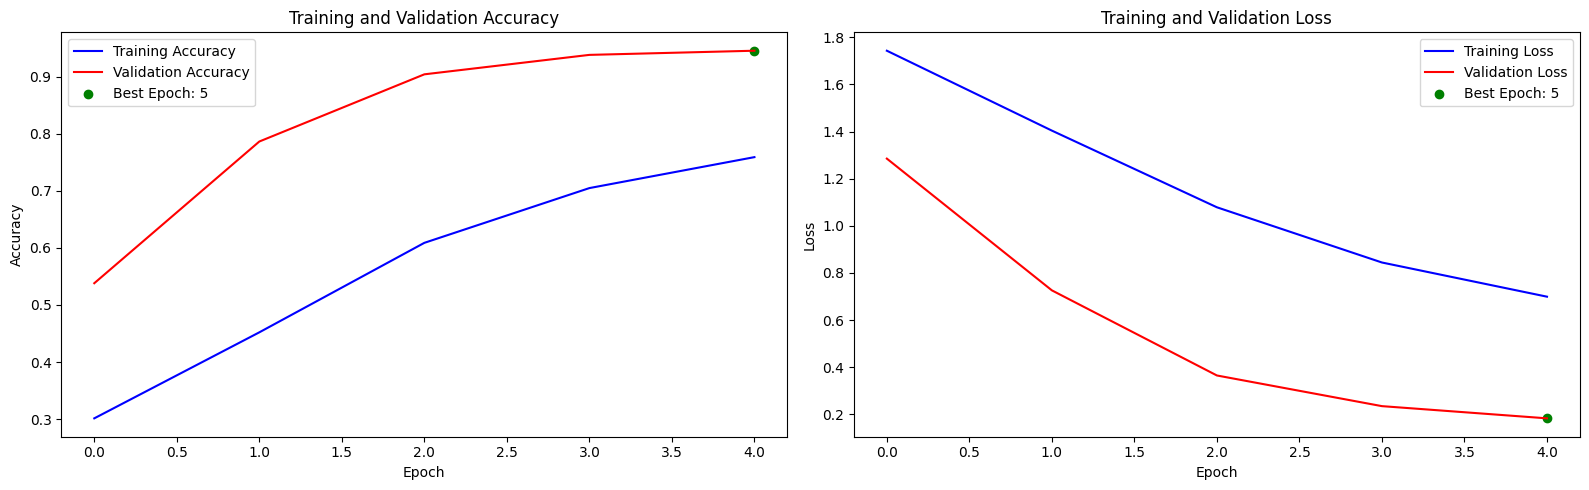

In [42]:
# Get the epoch with the highest validation accuracy
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

# Create a subplot with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(16,5))

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axs[0].scatter(best_epoch - 1, history.history['val_accuracy'][best_epoch - 1], color='green', label=f'Best Epoch: {best_epoch}')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()


# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss', color='blue')
axs[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
axs[1].scatter(best_epoch - 1, history.history['val_loss'][best_epoch - 1], color='green',label=f'Best Epoch: {best_epoch}')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">Test Accuracy</p>

In [44]:
# Evaluate Test Data

# Reshape X_test_padded to match the 3D input shape expected by the GRU model
X_test_reshaped_for_eval = X_test_padded.reshape(X_test_padded.shape[0], 1, maxlen)

# One-hot encode y_test_processed for evaluation, using the previously fitted encoder
y_test_one_hot_for_eval = encoder.transform(y_test_processed.values.reshape(-1, 1))

model.evaluate(X_test_reshaped_for_eval, y_test_one_hot_for_eval)

3743/3743 ━━━━━━━━━━━━━━━━━━━━ 243s 65ms/step - accuracy: 0.9456 - loss: 0.1830


[0.18300728499889374, 0.945590078830719]

In [46]:
# Predictions On Test For Confustion Matrix
from sklearn.metrics import confusion_matrix

# Reshape X_test_padded to match the 3D input shape expected by the GRU model
X_test_reshaped_for_pred = X_test_padded.reshape(X_test_padded.shape[0], 1, maxlen)

y_pred = model.predict(X_test_reshaped_for_pred)
y_pred = np.argmax(y_pred, axis=1)

3743/3743 ━━━━━━━━━━━━━━━━━━━━ 192s 51ms/step


<Axes: >

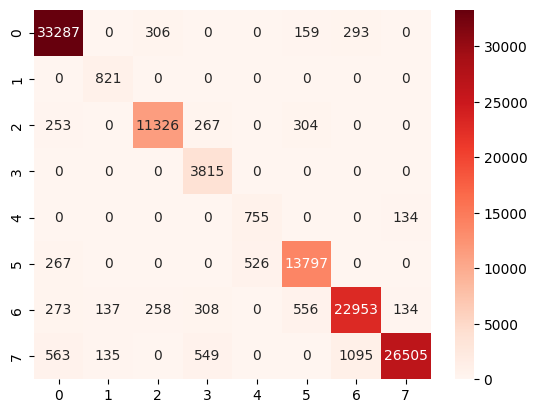

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

<Axes: >

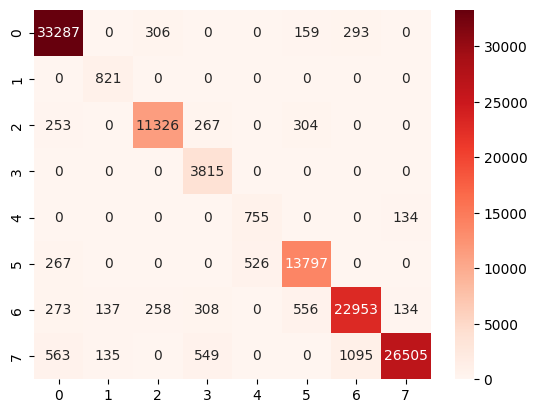

In [48]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

In [49]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     34045
           1       0.75      1.00      0.86       821
           2       0.95      0.93      0.94     12150
           3       0.77      1.00      0.87      3815
           4       0.59      0.85      0.70       889
           5       0.93      0.95      0.94     14590
           6       0.94      0.93      0.94     24619
           7       0.99      0.92      0.95     28847

    accuracy                           0.95    119776
   macro avg       0.86      0.94      0.90    119776
weighted avg       0.95      0.95      0.95    119776



### Investigating Class 4 Samples

From the classification report, we observe that `class 4` has 0.0 for precision, recall, and f1-score, indicating that the model completely failed to predict any samples belonging to this class. Let's investigate what this class represents and examine some of its samples.

In [50]:
# Find the original label corresponding to the remapped class 4
# The label_mapping is {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7}
original_label_for_class_4 = [k for k, v in label_mapping.items() if v == 4][0]
print(f"The remapped class 4 corresponds to the original label '{original_label_for_class_4}'.")

# Filter the DataFrame for samples belonging to class 4 (original label '5')
class_4_samples = df[df['Label'] == 4]

print(f"\nNumber of samples in class 4 (original label '{original_label_for_class_4}'): {len(class_4_samples)}")
print("\nFirst 10 samples from class 4 (original label '5'):")
display(class_4_samples['tweet'].head(10))

The remapped class 4 corresponds to the original label '5'.

Number of samples in class 4 (original label '5'): 4482

First 10 samples from class 4 (original label '5'):


,tweet
295969,feel sickened disgusted sins man despite divin...
296087,feel rather disgusted seeing photography
297546,feel sickened disgusted sins man despite divin...
297547,feel rather disgusted seeing photography
297548,feel sickened disgusted sins man despite divin...
297549,feel rather disgusted seeing photography
297550,feel sickened disgusted sins man despite divin...
297551,feel rather disgusted seeing photography
297552,feel sickened disgusted sins man despite divin...
297553,feel rather disgusted seeing photography


The samples for class 4 (original label '5') seem to often contain words related to negative emotions like 'sickened', 'disgusted', 'disappointing', 'hate', etc. It's possible that these specific terms, or the context in which they appear, are not being adequately captured or distinguished by the model, or they are very similar to other negative emotion classes. We will now investigate further by looking at the predictions specifically on these samples.

In [52]:
# Create a boolean mask for class 4 samples in the test set
mask_class_4 = (y_test_processed == 4)

# Filter X_test_padded and y_test_processed using the boolean mask
X_test_class_4_padded = X_test_padded[mask_class_4]
y_test_class_4 = y_test_processed[mask_class_4]

# Reshape X_test_class_4_padded to match the 3D input shape expected by the GRU model
X_test_class_4_reshaped = X_test_class_4_padded.reshape(X_test_class_4_padded.shape[0], 1, maxlen)

# Make predictions on these specific class 4 samples
predictions_class_4 = model.predict(X_test_class_4_reshaped)
predicted_labels_class_4 = np.argmax(predictions_class_4, axis=1)

print(f"\nNumber of class 4 samples in the test set: {len(y_test_class_4)}")
print("\nDistribution of predicted labels for class 4 samples:")
print(pd.Series(predicted_labels_class_4).value_counts())

# Display some of the misclassified samples if any, and what they were predicted as
misclassified_indices = np.where(predicted_labels_class_4 != 4)[0]
if len(misclassified_indices) > 0:
    print(f"\nFirst 10 misclassified class 4 samples from X_test and their predicted labels (original text from df):")
    # Get the original text from the df using the index of the original X_test
    original_X_test_indices_for_class_4 = X_test[mask_class_4].index
    for i in misclassified_indices[:10]:
        original_index_in_df = original_X_test_indices_for_class_4[i]
        print(f"Original text: {df.loc[original_index_in_df, 'tweet']}")
        print(f"Actual Label: {y_test_class_4.iloc[i]}, Predicted Label: {predicted_labels_class_4[i]}\n")
else:
    print("\nNo misclassified class 4 samples found. This should not happen given the classification report.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step

Number of class 4 samples in the test set: 889

Distribution of predicted labels for class 4 samples:
4    755
7    134
Name: count, dtype: int64

First 10 misclassified class 4 samples from X_test and their predicted labels (original text from df):
Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

Original text: feel need keep entertained feel like youre bored
Actual Label: 4, Predicted Label: 7

O

In [ ]:
Hypertuned_GRU_pred = model.predict(X_test_padded) # Predict using the correct X_test

2967/2967 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step


In [ ]:
Hypertuned_GRU_pred = np.argmax(Hypertuned_GRU_pred, axis=-1) # Changed prediction processing for multi-class

In [58]:
from sklearn.metrics import accuracy_score
print("Unique values in y_test:", np.unique(y_test))
print("Value counts in y_pred:", pd.Series(y_pred).value_counts())
Hypertuned_GRU_Accuracy = accuracy_score(y_test, y_pred)*100 # Corrected argument order
print("Hypertuned_GRU_Accuracy Score is :",Hypertuned_GRU_Accuracy,'%')

Unique values in y_test: [0 1 2 3 4 5 6 7]
Value counts in y_pred: 0    34643
7    26773
6    24341
5    14816
2    11890
3     4939
4     1281
1     1093
Name: count, dtype: int64
Hypertuned_GRU_Accuracy Score is : 94.55901015228426 %


In [59]:
from sklearn.metrics import classification_report
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
0,0.960858,0.977735,0.969223,34045.00000
1,0.751144,1.000000,0.857889,821.00000
2,0.952565,0.932181,0.942263,12150.00000
3,0.772424,1.000000,0.871602,3815.00000
4,0.589383,0.849269,0.695853,889.00000
5,0.931223,0.945648,0.938380,14590.00000
6,0.942977,0.932329,0.937623,24619.00000
7,0.989990,0.918813,0.953074,28847.00000
accuracy,0.945590,0.945590,0.945590,0.94559
macro avg,0.861320,0.944497,0.895738,119776.00000


In [60]:
from sklearn.metrics import accuracy_score

In [61]:
# Predictions On Test For Confustion Matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test_padded)
y_pred = np.argmax(y_pred, axis=1)

3743/3743 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step


In [62]:
print("Unique values in y_test:", np.unique(y_test))
print("Value counts in y_pred:", pd.Series(y_pred).value_counts())
GRUMODELA = accuracy_score(y_test, y_pred)*100 # Corrected argument order
print("LSTM_Accuracy Score is :",GRUMODELA,'%')

Unique values in y_test: [0 1 2 3 4 5 6 7]
Value counts in y_pred: 0    33595
7    28424
6    24626
5    15153
2    12150
3     3817
1     1093
4      918
Name: count, dtype: int64
LSTM_Accuracy Score is : 98.61825407427197 %


In [63]:
# Create a DataFrame with these accuracy scores
data = {
    'Model': ['Hypertuned GRU', 'GRU Model A'],
    'Accuracy': [Hypertuned_GRU_Accuracy, GRUMODELA]
}
Acc_df = pd.DataFrame(data)

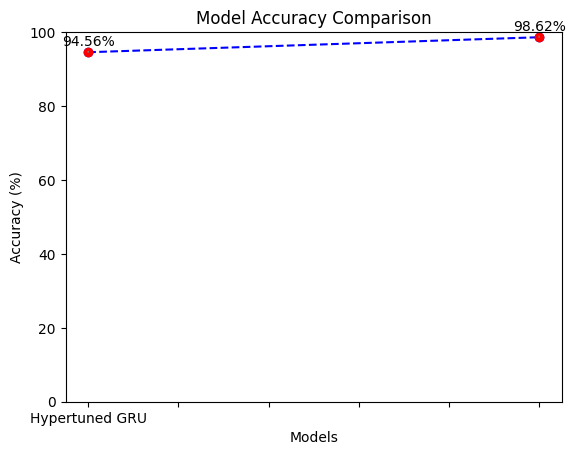

In [64]:
# Plot the DataFrame
ax = Acc_df.plot(x='Model', y='Accuracy', marker='o', linestyle='dashed', color='b', legend=False)

# Add labels, title, and customize the plot
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0, 100)  # Set the y-axis limits for percentage values from 0 to 100

# Highlight the points and add value labels
for i, accuracy in enumerate(Acc_df['Accuracy']):
    ax.annotate(f'{accuracy:.2f}%', xy=(i, accuracy), xytext=(i, accuracy + 1), # Adjusted xytext for better label visibility
                ha='center', va='bottom', fontsize=10, color='black',
                arrowprops=dict(arrowstyle='-', color='gray'))
    ax.plot(i, accuracy, 'ro')  # Highlight points with red color

# Show the plot
plt.show()


# <p style="font-family:newtimeroman;font-size:100%;text-align:center;color:#6A5ACD;">The End</p>